# 02 — Séries, ciclos mensais e mapas com cobertura automática

Os notebooks usam somente partições mensais NetCDF processadas, presentes no disco e verificadas por SHA-256 no manifesto SQLite. Não exigem consolidação Zarr nem igual cobertura entre poluentes. Não baixam arquivos, não alteram o manifesto e não inferem observações ausentes.

Datas, variáveis e anos são descobertos a cada execução. Arquivos brutos sem processamento, caminhos quebrados, checksum incorreto, duplicidade de partições e escopos incompatíveis são reportados. Arquivos órfãos fora do manifesto não são incorporados automaticamente. A cobertura é a local: não prova completude de toda a série publicada no ADS.

Meses com qualquer célula espacial não finita são excluídos das médias espaciais para manter domínio constante. Anos completos têm 12 meses utilizáveis. Dois ou mais anos completos permitem uma **referência empírica multianual**, não necessariamente uma normal climatológica de 30 anos. Anos não consecutivos são permitidos e listados. A referência muda quando a base cresce; JSON e diretórios de execução preservam a seleção usada. Com menos de dois anos completos, há ciclo mensal descritivo e não há produto de anomalias. Gases conservam as unidades do arquivo.


In [1]:
NOTEBOOK = "02_global_climatology"
from pathlib import Path
from datetime import datetime, timezone
import os
import sys
import json
import pandas as pd
from IPython.display import display, Image

# Execute da pasta do projeto ou de notebooks/. Configuração alternativa é opcional.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "config/config.yaml").is_file()), None)
if ROOT is None:
    raise RuntimeError("Execute o notebook dentro do projeto que contém config/config.yaml.")
sys.path.insert(0, str(ROOT / "notebooks"))
from cams_air_quality.config import load_config
from available_data import inventory, open_variable, coverage, analyze, point_and_region

CONFIG_PATH = Path(os.environ.get("CAMSAQ_CONFIG", ROOT / "config/config.yaml"))
cfg = load_config(CONFIG_PATH)
VARIABLES = None  # None: todas as variáveis mensais processadas encontradas neste escopo.
RUN_ID = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%S%fZ")
OUT = Path(cfg["root"]) / "reports" / "automatic_notebooks" / NOTEBOOK / RUN_ID
OUT.mkdir(parents=True, exist_ok=True)
rows, file_report = inventory(cfg, VARIABLES)
file_report.to_csv(OUT / "file_inventory.csv", index=False)
variables = sorted({r["variable"] for r in rows})
print("Configuração:", CONFIG_PATH)
print("Variáveis com arquivos processados íntegros:", variables)
print("Saídas:", OUT)
if not variables:
    print("Sem dados elegíveis. Confira o inventário; execute camsaq validate e camsaq process --kind monthly.")
display(file_report)


Configuração: /home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/config/config.yaml
Variáveis com arquivos processados íntegros: ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2']
Saídas: /home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/reports/automatic_notebooks/02_global_climatology/20261002T203018061459Z


,variable,year,month,status,file,key
0,pm25,2003,1,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,87db452ca5ea5329e3bedfcbec3d4bb67ba431efe403dd...
1,co,2003,1,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,4e79bce714a8e6afba25ccd3415d6ba14b43687efb90a1...
2,no2,2003,1,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,06414146cbcef0344d74fa1c800448d010c1fb989fce5e...
3,pm10,2003,1,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,1ec4c8f27fa15ec5ed1d12d28b055051d6266386db9cdc...
4,o3,2003,1,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,b41272da3bc2a33f11cb1b4737f0bb11976222ca0d8de0...
...,...,...,...,...,...,...
70,pm25,2003,12,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,3fe503decb18b9c26249945b69fe2fad8b8bc2cba71108...
71,so2,2003,12,ready,/home/paulo/Documentos/meus_codigos/cams/cams-...,ef607b6960f7dc1edc1813c0283dd9f32130ded2017b44...
72,co,2004,1,failed,/home/paulo/Documentos/meus_codigos/cams/cams-...,56664f643b70aa1a066f16d0ef99040cfb7ce682bf0d1b...
73,no2,2004,1,failed,/home/paulo/Documentos/meus_codigos/cams/cams-...,20e60f725728aa655a49ee90397a6f71b1ecc24283f205...


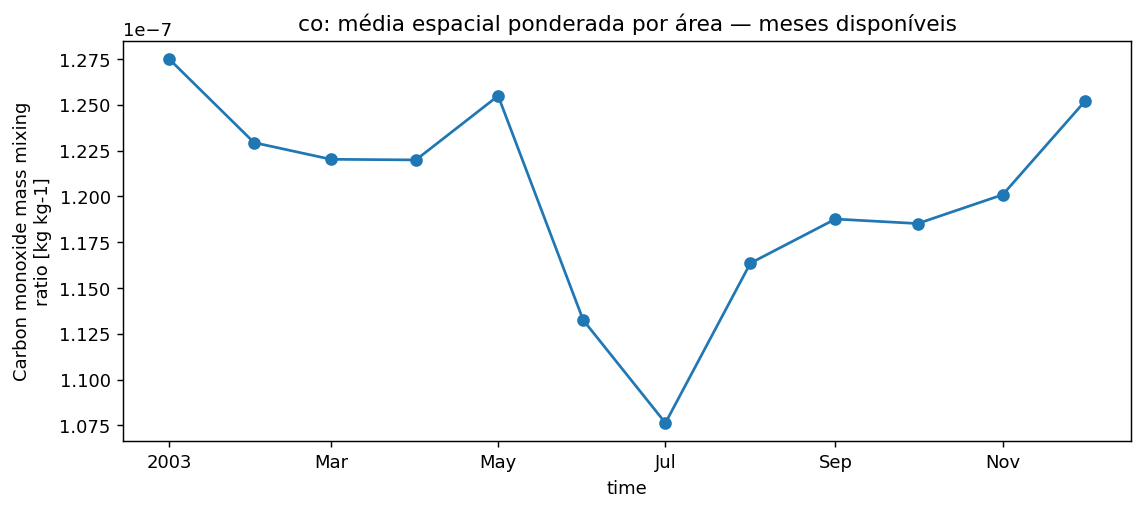

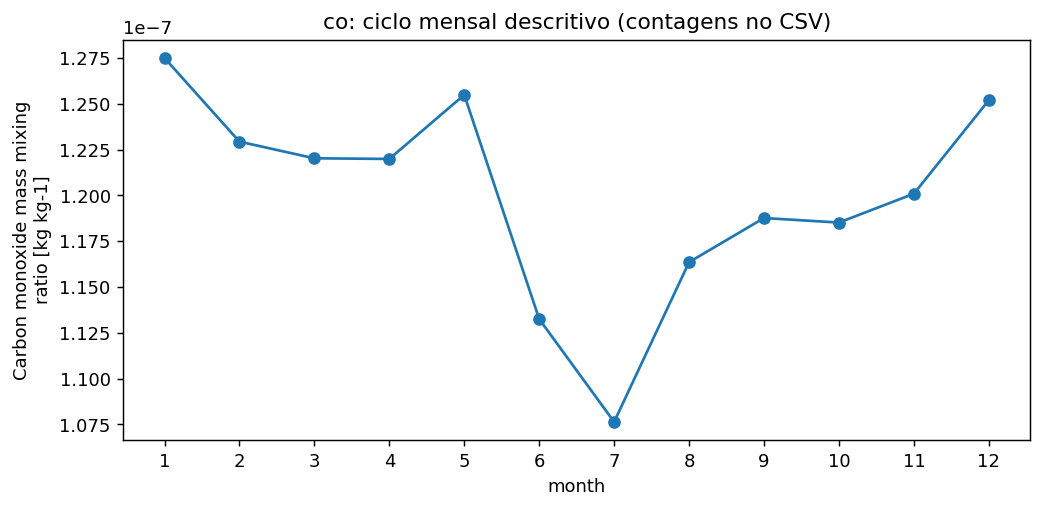

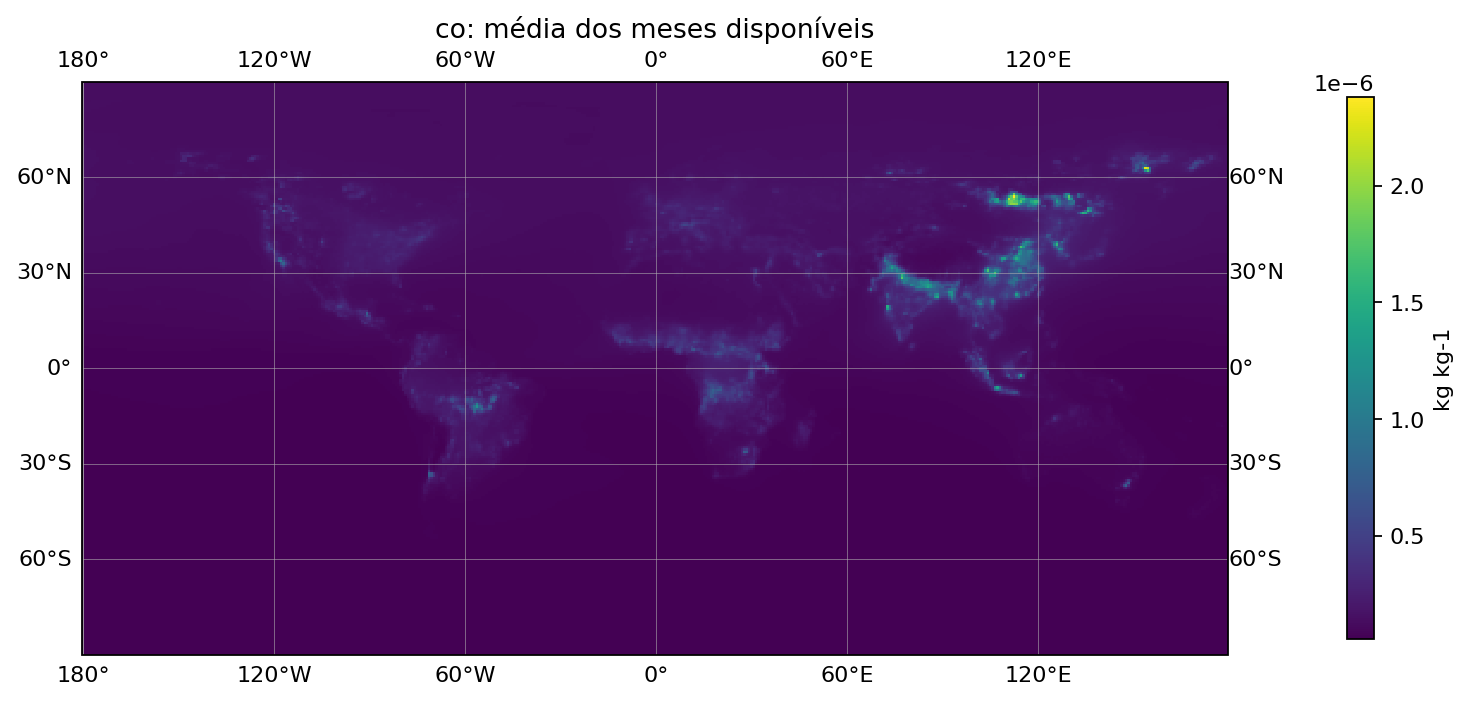

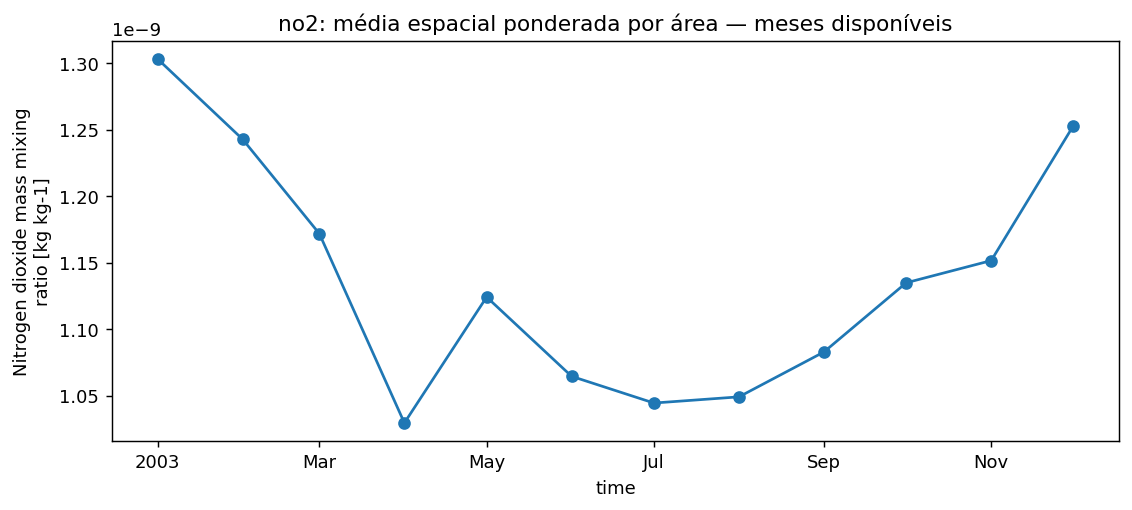

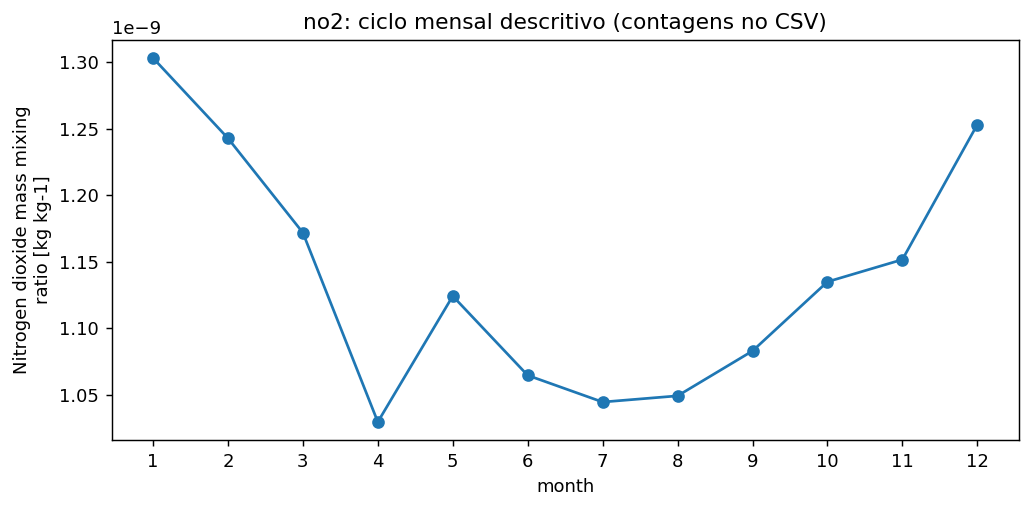

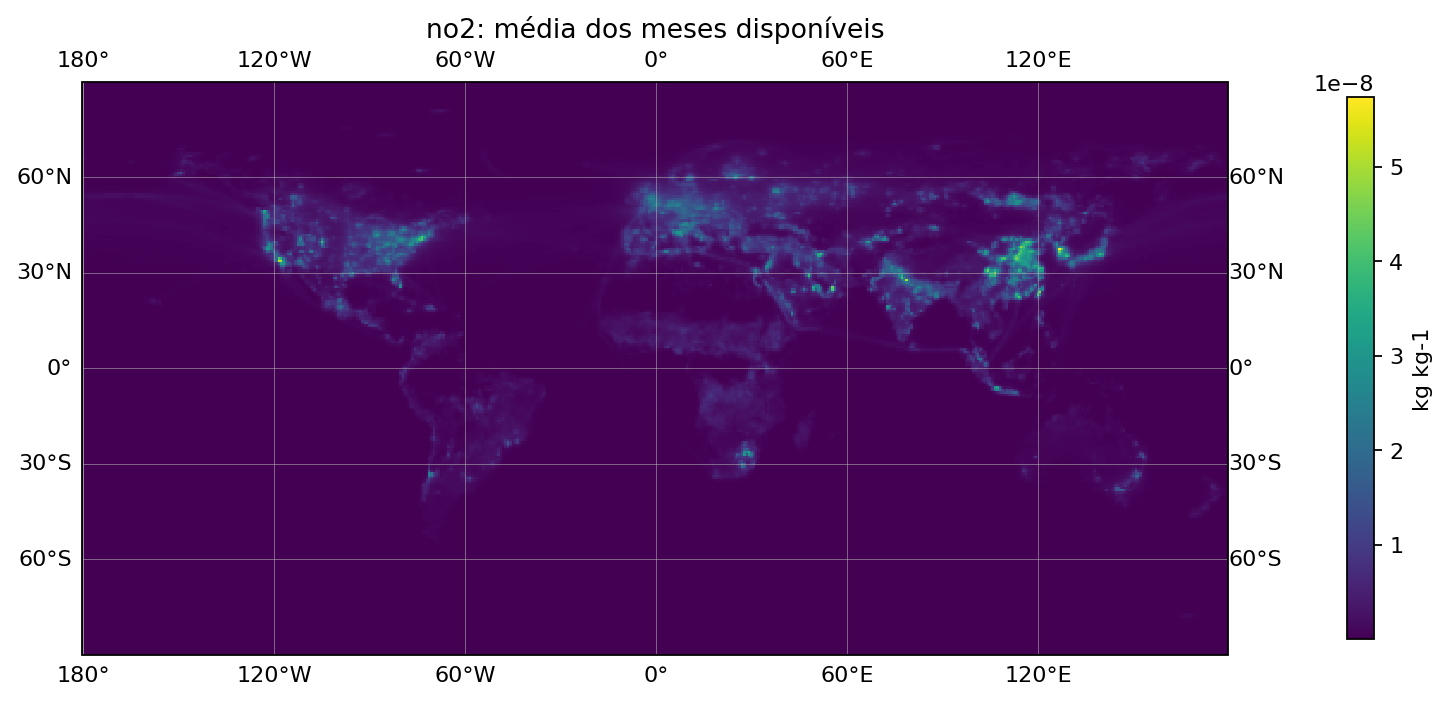

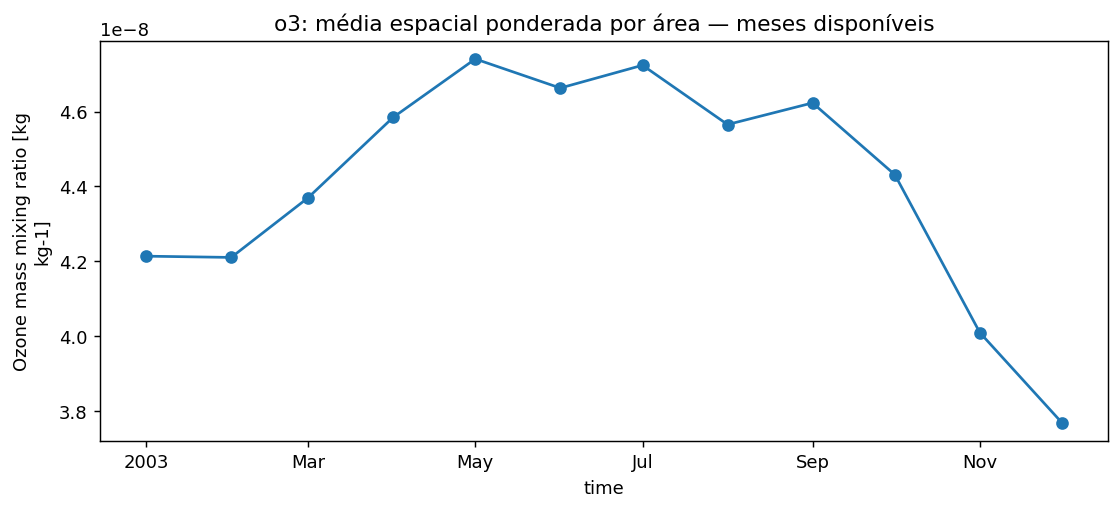

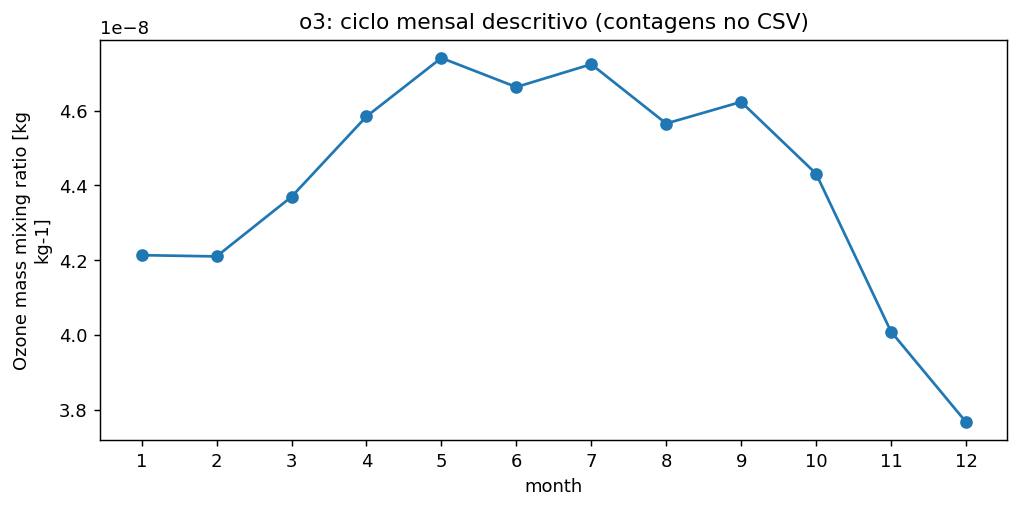

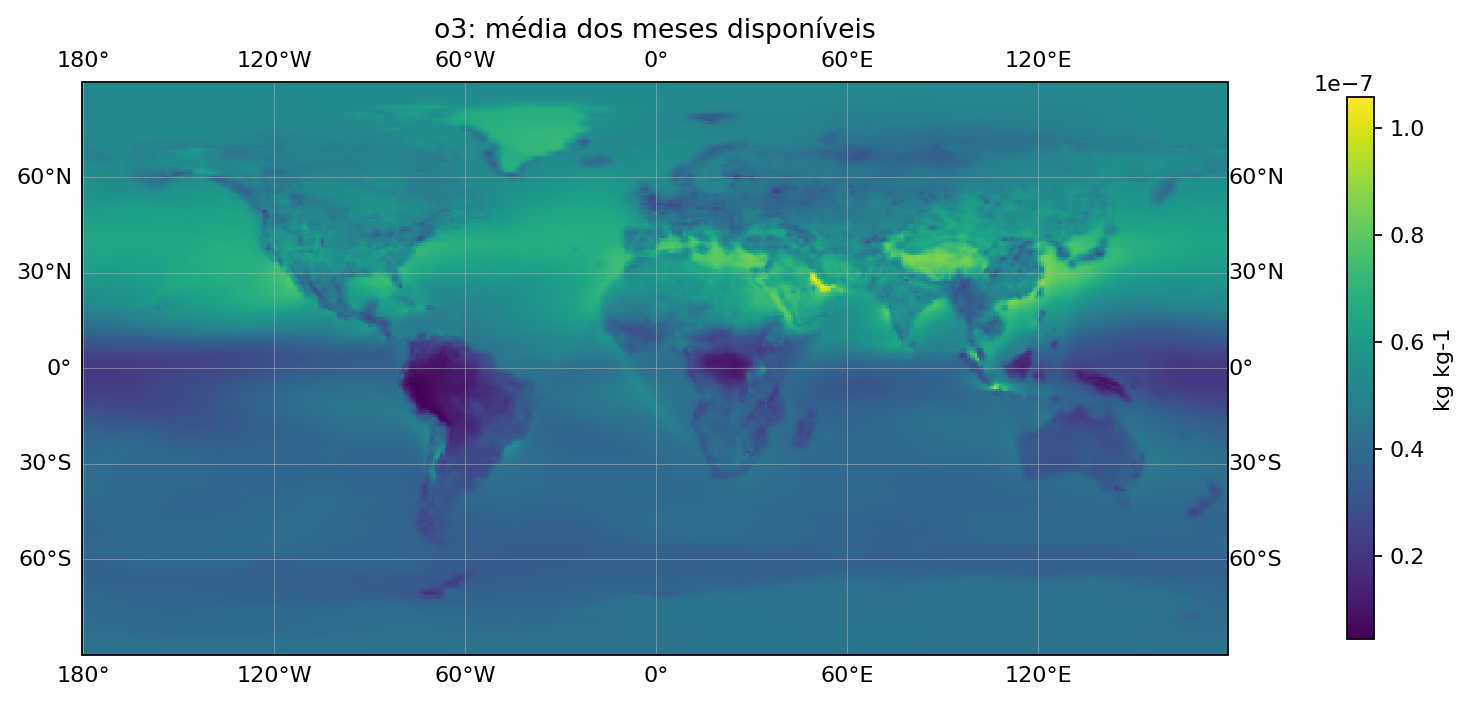

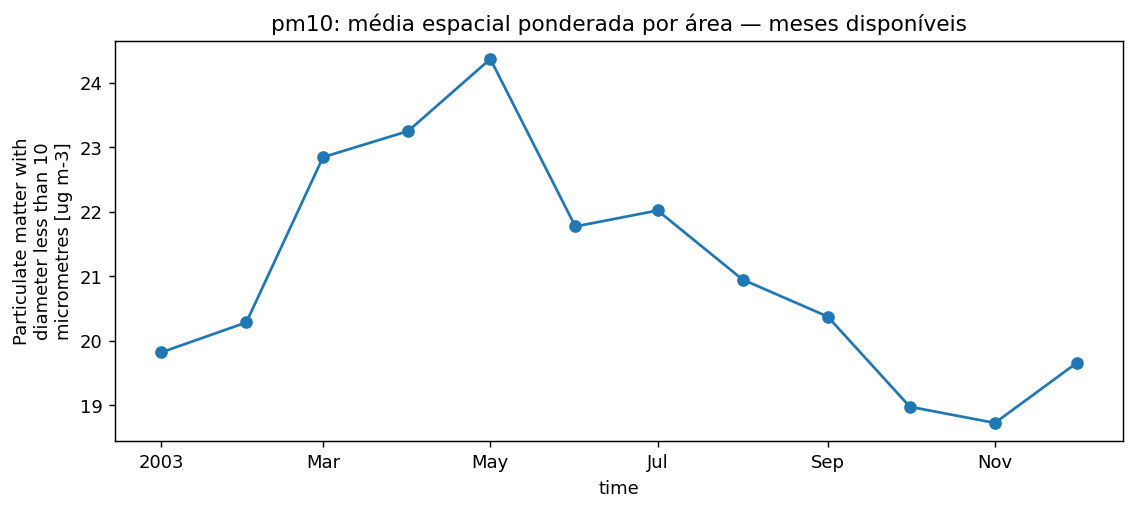

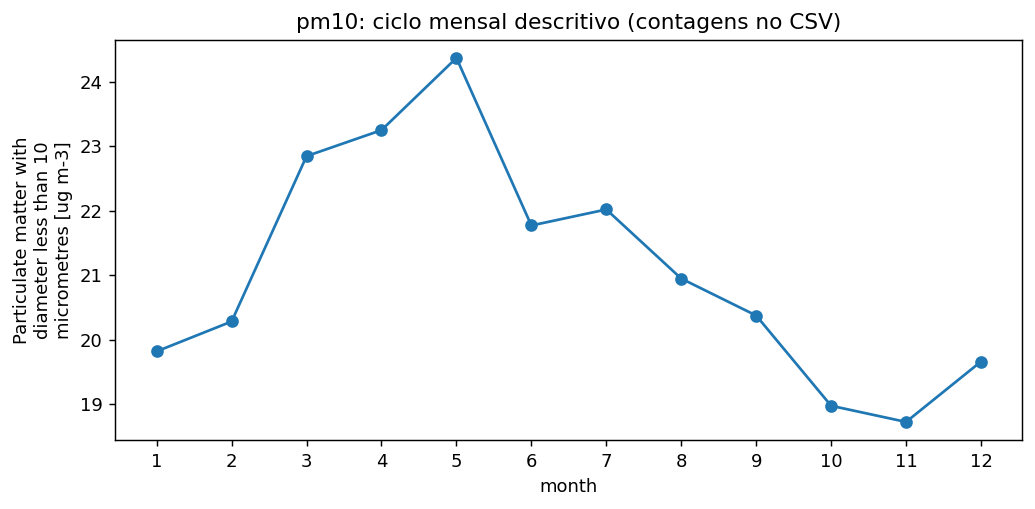

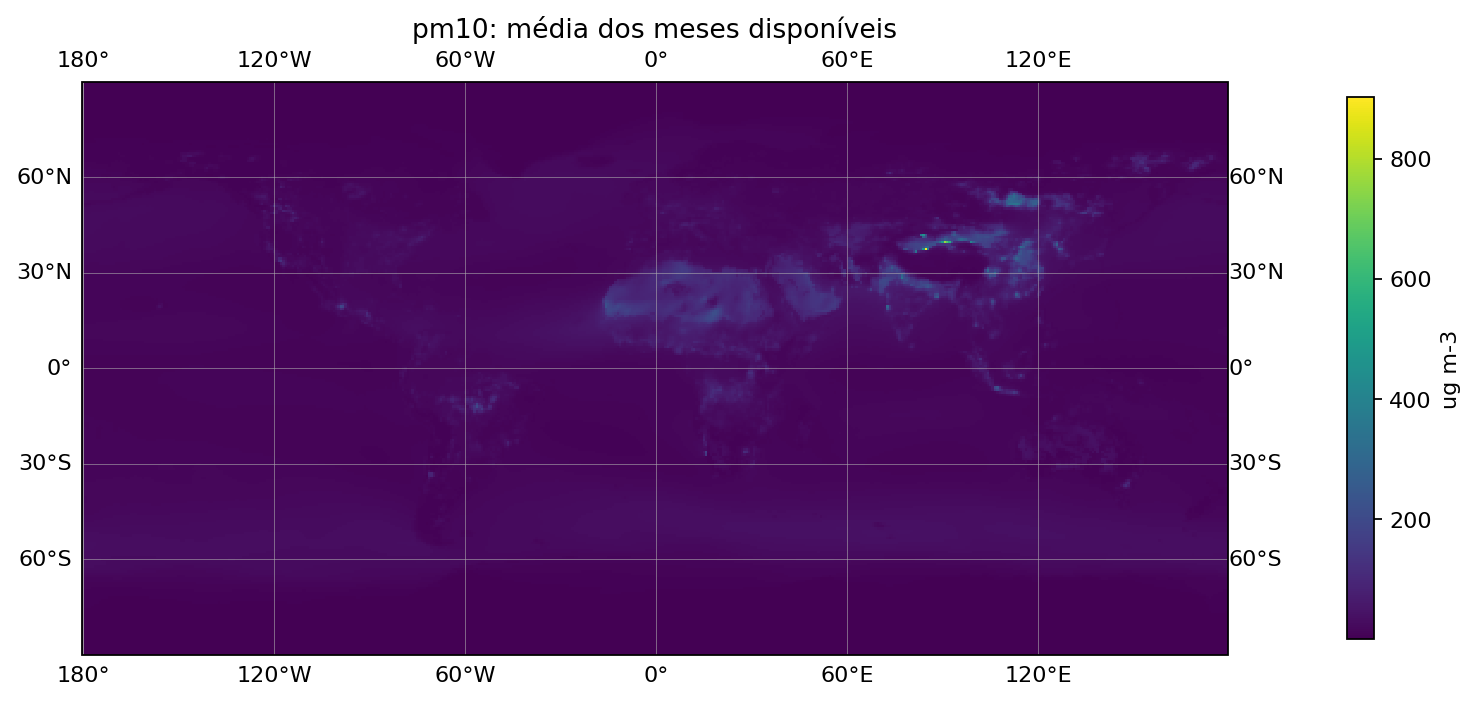

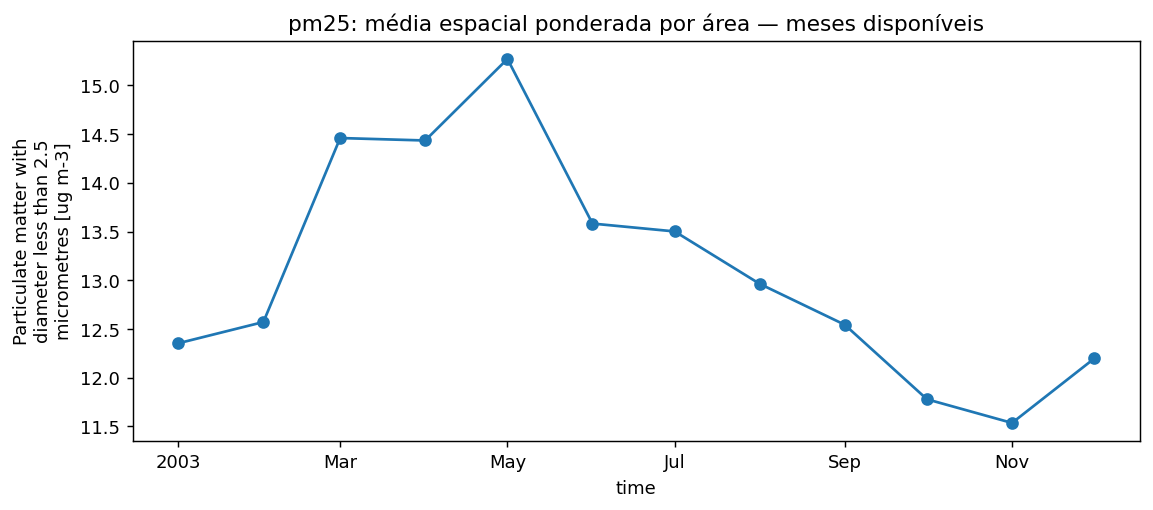

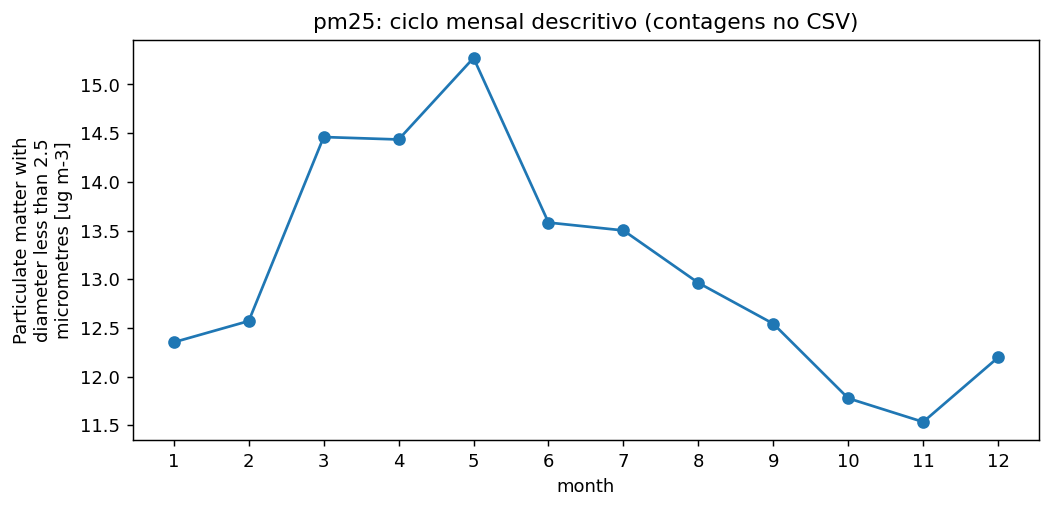

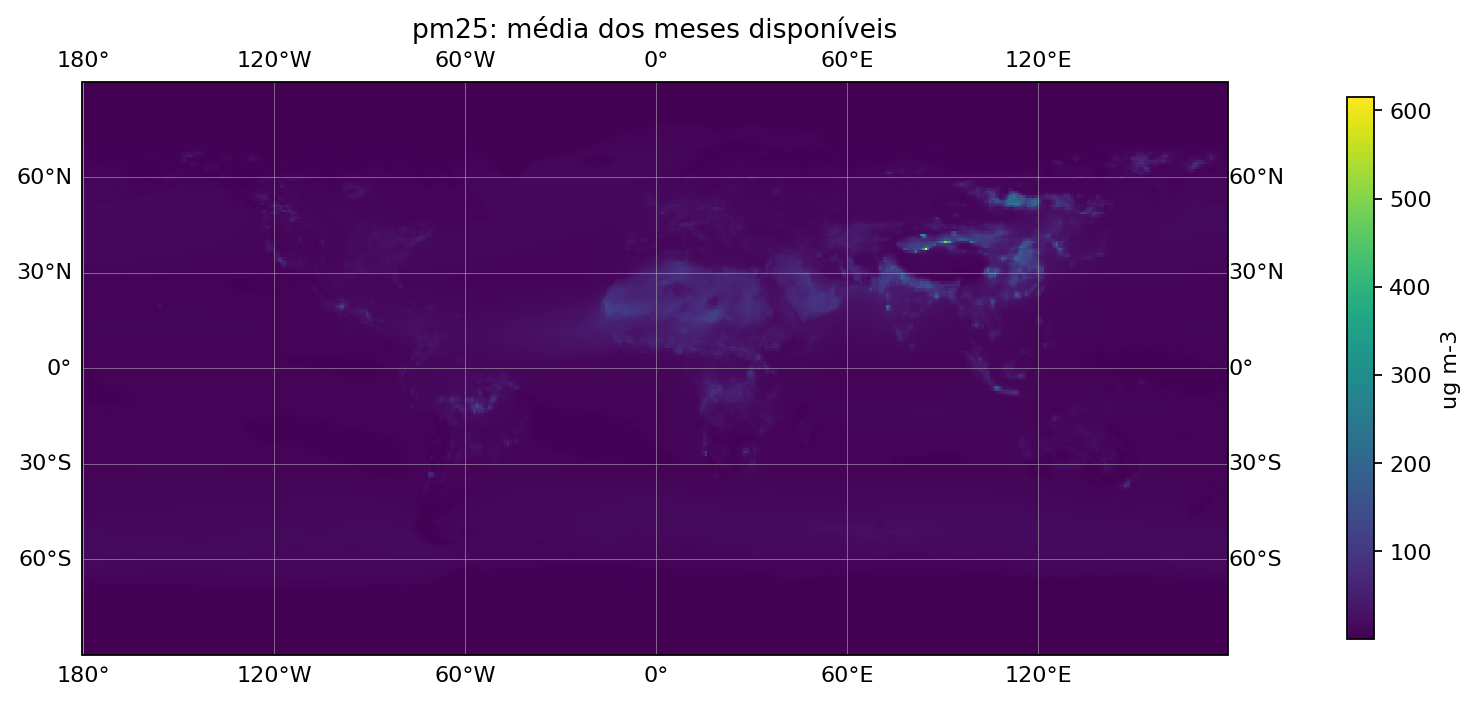

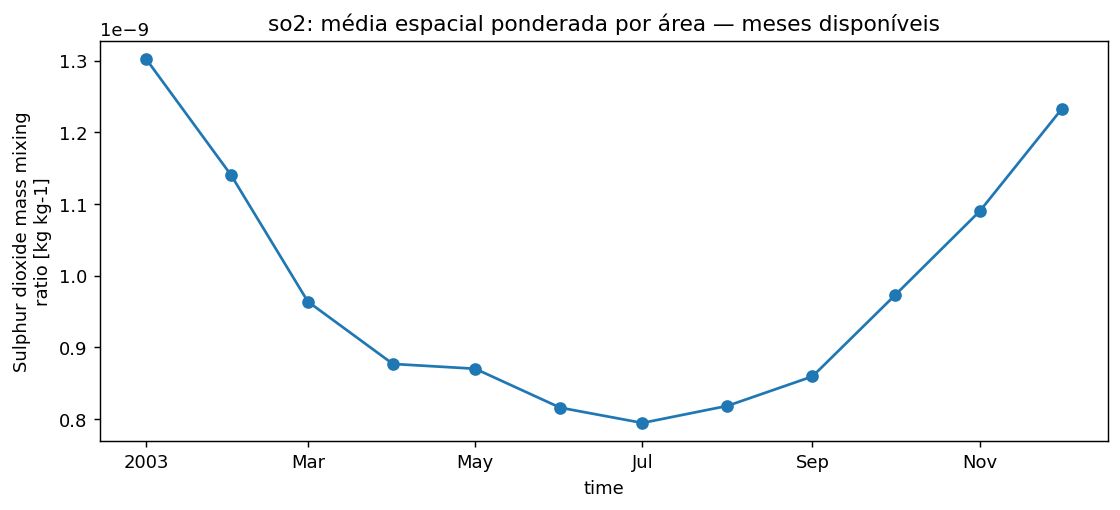

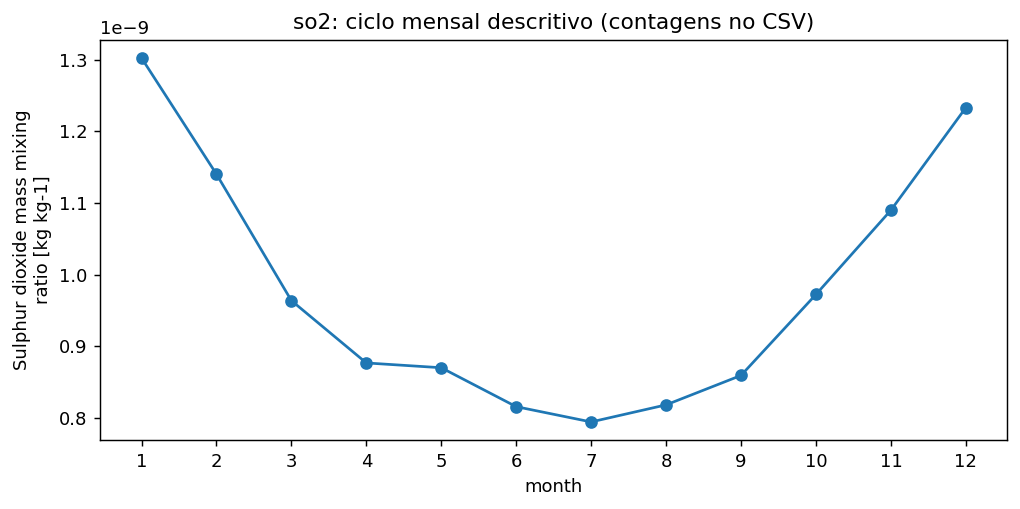

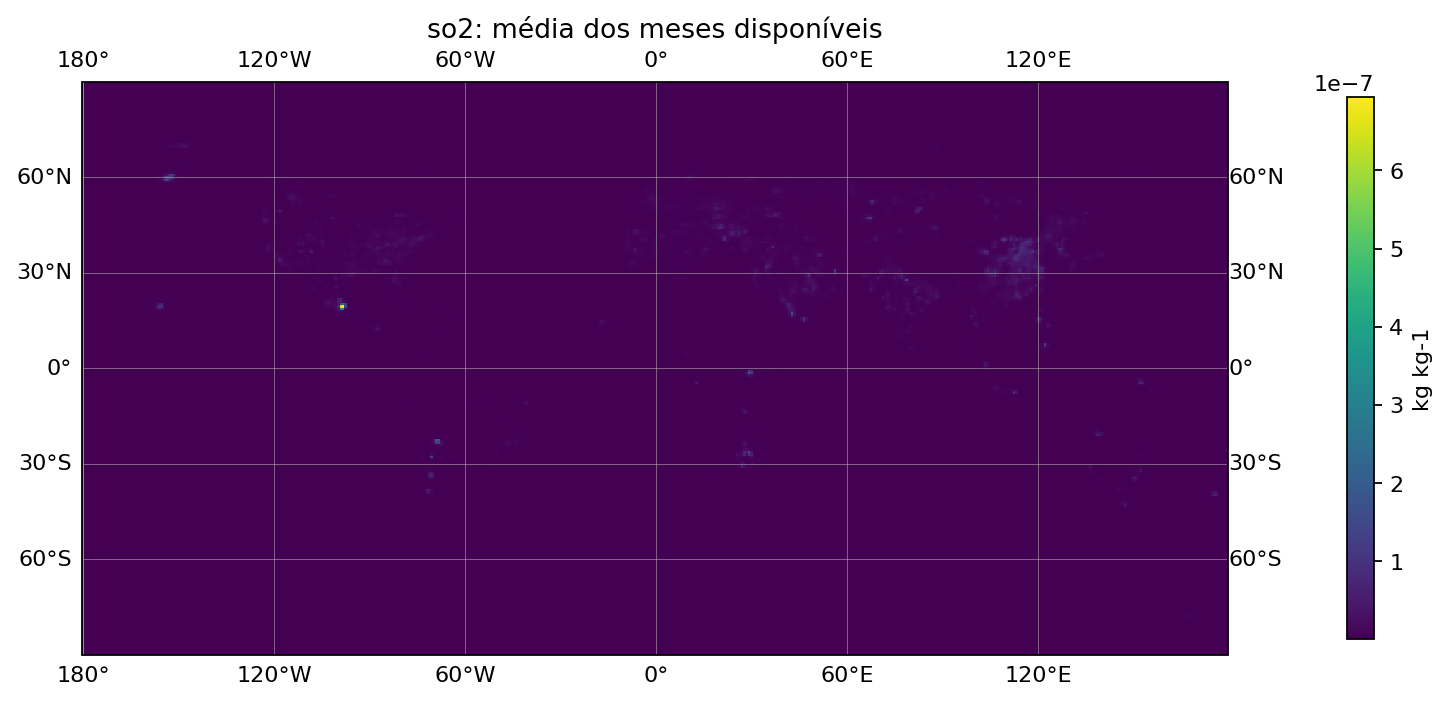

,first_observed,last_observed,months_observed,months_usable,months_expected_between_endpoints,missing_months,invalid_months,complete_years,reference_years,units,helper_sha256,qc_policy,reference_policy,climatology_status,source,variable,bbox,configured_area,created_at
0,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],kg kg-1,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,co,None,None,2026-10-02T20:30:22.776928+00:00
1,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],kg kg-1,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,no2,None,None,2026-10-02T20:30:38.909283+00:00
2,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],kg kg-1,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,o3,None,None,2026-10-02T20:30:55.205249+00:00
3,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],ug m-3,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,pm10,None,None,2026-10-02T20:31:11.741522+00:00
4,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],ug m-3,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,pm25,None,None,2026-10-02T20:31:27.750467+00:00
5,2003-01-01,2003-12-01,12,12,12,[],[],[2003],[],kg kg-1,83931389cbb280b43ba7bcc152f483a36c403e98dcc0bc...,All grid cells finite in each included month; ...,All available complete calendar years; may be ...,monthly_cycle_only,EAC4,so2,None,None,2026-10-02T20:31:43.798173+00:00


Falhas: 0 — todos os mapas e tabelas: /home/paulo/Documentos/meus_codigos/cams/cams-global-air-quality/reports/automatic_notebooks/02_global_climatology/20261002T203018061459Z


In [2]:
# None: domínio disponível; se cfg.area não for global, a média é regional.
BBOX = None  # Exemplo de recorte: [-20, -55, -26, -40] = norte, oeste, sul, leste.
GENERATE_MAPS = True
summaries, errors = [], []
for variable in variables:
    try:
        summaries.append(analyze(variable, rows, cfg, OUT, bbox=BBOX, maps=GENERATE_MAPS))
        for name in ("timeseries.png", "monthly_cycle.png", "available_period_mean.png"):
            image = OUT / variable / name
            if image.is_file():
                display(Image(filename=str(image)))
    except Exception as exc:
        errors.append({"variable": variable, "error": str(exc)})
        print("ERRO —", variable, exc)
(OUT / "summary.json").write_text(json.dumps(summaries, indent=2), encoding="utf-8")
(OUT / "errors.json").write_text(json.dumps(errors, indent=2), encoding="utf-8")
display(pd.DataFrame(summaries).drop(columns=["files"], errors="ignore"))
print("Falhas:", len(errors), "— todos os mapas e tabelas:", OUT)

O mapa mensal usa o último mês válido de cada variável. O mapa anual usa seu último ano completo. A média do período pondera pelos dias de cada mês disponível, com cobertura registrada. O ciclo mensal informa a contagem de amostras por mês. Anomalias usam somente os anos completos identificados e podem incluir o ano avaliado. Não se interpreta um período curto como tendência climática. Médias espaciais não são ponderadas pela população. Para mapas regionais, escolha BBOX; recortes com menos de dois centros em alguma direção não suportam o renderizador atual. Recortes que cruzam o antimeridiano permitem séries, mas seus mapas são omitidos explicitamente.